## Imports and fetch data

In [1]:
import os
import sys

sys.path.insert(0, os.path.abspath('..'))  # Add parent folder

In [2]:
from collections import Counter

import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

from src.competitors import (
    export_results,
    get_rezaeian_features,
    get_kurniadi_features,
    map_competitor_features,
)
from src.utils import *

In [3]:
# Load and Filter for Luminal A
_, df_LumA = load_metabric_data()

Fetching METABRIC dataset from Kaggle...

Original dataset was loaded, shape: (1904, 693)
Original dataset was preprocessed, given a new shape: (679, 684)


In [4]:
df_LumA.info()

<class 'pandas.DataFrame'>
Index: 679 entries, 1 to 1899
Columns: 684 entries, age_at_diagnosis to target_mortality
dtypes: float64(497), int64(1), str(186)
memory usage: 3.5 MB


In [5]:
df_LumA['target_mortality'].value_counts()

target_mortality
0    533
1    146
Name: count, dtype: int64

## Investigate feature space of distinct approaches

### Competitor methods

In [6]:
rezaeian_list = get_rezaeian_features()

features_rezaeian = map_competitor_features(df_LumA.columns, rezaeian_list)

Available columns (first 5):  Index(['age_at_diagnosis', 'cancer_type_detailed', 'cellularity', 'cohort',
       'er_status_measured_by_ihc'],
      dtype='str')
Competitor's columns (first 5): ['bbc3', 'cdkn2a', 'wfdc2', 'hes2', 'hsd3b7']

Strict Mapping: 
Found exactly 39 features for the 39 target variables.


In [7]:
counts, _, _, _ = count_feature_categories(rezaeian_list)
counts

{'Clinical Attributes': 0, 'm-RNA levels z-score': 39, 'Mutation': 0}

In [8]:
kurniadi_list = get_kurniadi_features()

features_kurniadi = map_competitor_features(df_LumA.columns, kurniadi_list)

Available columns (first 5):  Index(['age_at_diagnosis', 'cancer_type_detailed', 'cellularity', 'cohort',
       'er_status_measured_by_ihc'],
      dtype='str')
Competitor's columns (first 5): ['rab25', 'eif5a2', 'pik3ca', 'kit', 'fgf1']

Strict Mapping: 
Found exactly 15 features for the 15 target variables.


In [9]:
counts, _, _, _ = count_feature_categories(kurniadi_list)
counts

{'Clinical Attributes': 0, 'm-RNA levels z-score': 15, 'Mutation': 0}

### Proposed approaches

In [10]:
X, y, kept_columns, categorical_columns = build_metabric_pipeline(df_LumA)
X.shape, y.value_counts()


Applying one-hot encoding to categorical columns: 
cancer_type_detailed               5 levels
er_status_measured_by_ihc          2 levels
her2_status_measured_by_snp6       4 levels
tumor_other_histologic_subtype     6 levels
inferred_menopausal_state          2 levels
integrative_cluster               11 levels
primary_tumor_laterality           2 levels
oncotree_code                      5 levels
3-gene_classifier_subtype          3 levels
dtype: str

---------


New columns after one-hot encoding:
3-gene_classifier_subtype_ER+/HER2- Low Prolif
3-gene_classifier_subtype_HER2+
cancer_type_detailed_Breast Invasive Ductal Carcinoma
cancer_type_detailed_Breast Invasive Lobular Carcinoma
cancer_type_detailed_Breast Invasive Mixed Mucinous Carcinoma
cancer_type_detailed_Breast Mixed Ductal and Lobular Carcinoma
er_status_measured_by_ihc_Positve
her2_status_measured_by_snp6_LOSS
her2_status_measured_by_snp6_NEUTRAL
her2_status_measured_by_snp6_UNDEF
inferred_menopausal_state_Pre
integrati

((679, 705),
 target_mortality
 0    533
 1    146
 Name: count, dtype: int64)

In [11]:
features_suggested_approach = map_competitor_features(df_LumA.columns, kept_columns)

Available columns (first 5):  Index(['age_at_diagnosis', 'cancer_type_detailed', 'cellularity', 'cohort',
       'er_status_measured_by_ihc'],
      dtype='str')
Competitor's columns (first 5): ['age_at_diagnosis', 'cancer_type_detailed', 'cellularity', 'cohort', 'er_status_measured_by_ihc']

Strict Mapping: 
Found exactly 683 features for the 683 target variables.


In [12]:
counts, _, _, _ = count_feature_categories(kept_columns)
counts

{'Clinical Attributes': 21, 'm-RNA levels z-score': 489, 'Mutation': 173}

In [13]:
counts, _, _, _ = count_feature_categories(categorical_columns)
counts

{'Clinical Attributes': 9, 'm-RNA levels z-score': 0, 'Mutation': 0}

In [14]:
X, y, numerical_columns, categorical_columns = build_metabric_pipeline(df_LumA, kind="pure_numerical")
X.shape, y.value_counts()

((679, 498),
 target_mortality
 0    533
 1    146
 Name: count, dtype: int64)

In [15]:
features_suggested_approach = map_competitor_features(df_LumA.columns, X.columns.to_list())

Available columns (first 5):  Index(['age_at_diagnosis', 'cancer_type_detailed', 'cellularity', 'cohort',
       'er_status_measured_by_ihc'],
      dtype='str')
Competitor's columns (first 5): ['age_at_diagnosis', 'cellularity', 'cohort', 'neoplasm_histologic_grade', 'lymph_nodes_examined_positive']

Strict Mapping: 
Found exactly 498 features for the 498 target variables.


In [16]:
counts, _, _, _ = count_feature_categories(X.columns.to_list())
counts

{'Clinical Attributes': 9, 'm-RNA levels z-score': 489, 'Mutation': 0}

## Score any of the selected approaches with custom setup

In [17]:
X = df_LumA[features_kurniadi].copy()
y = df_LumA['target_mortality']

In [18]:
X.info()

<class 'pandas.DataFrame'>
Index: 679 entries, 1 to 1899
Data columns (total 15 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   rab25   679 non-null    float64
 1   eif5a2  679 non-null    float64
 2   pik3ca  679 non-null    float64
 3   kit     679 non-null    float64
 4   fgf1    679 non-null    float64
 5   myc     679 non-null    float64
 6   egfr    679 non-null    float64
 7   notch3  679 non-null    float64
 8   kras    679 non-null    float64
 9   akt1    679 non-null    float64
 10  erbb2   679 non-null    float64
 11  pik3r1  679 non-null    float64
 12  ccne1   679 non-null    float64
 13  akt2    679 non-null    float64
 14  aurka   679 non-null    float64
dtypes: float64(15)
memory usage: 84.9 KB


In [19]:
X.shape

(679, 15)

In [20]:
# Split & Scale
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [21]:
# Replicate the Grid Search from original benchmark
models_to_test = {
    'LogisticRegression': (LogisticRegression(max_iter=1000, random_state=42), {
        'C': [0.1, 1, 10], 'class_weight': ['balanced', None]
    }),
    'SVM': (SVC(probability=True, random_state=42), {
        'C': [0.1, 1, 10], 'kernel': ['rbf', 'linear'], 'class_weight': ['balanced', None]
    }),
    'RandomForest': (RandomForestClassifier(random_state=42), {
        'n_estimators': [50, 100, 200], 'max_depth': [3, 5, 10], 'class_weight': ['balanced', None]
    })
}

best_bench_model = None
best_score = 0
winner_name = ""

for name, (model, params) in models_to_test.items():
    grid = GridSearchCV(model, params, cv=5, scoring='roc_auc')
    grid.fit(X_train_scaled, y_train)
    if grid.best_score_ > best_score:
        best_score = grid.best_score_
        best_bench_model = grid.best_estimator_
        winner_name = name

In [22]:
best_bench_model

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",0.1
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",'balanced'
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


[SVM_Untuned] Threshold: 0.500 | AP: 0.317 | F1: 0.000


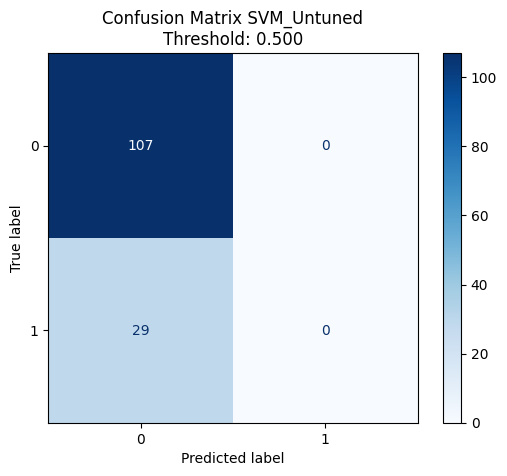

In [23]:
# Demonstrate WITHOUT tuning
y_pred_no_tune =export_results(best_bench_model, X_test_scaled, y_test,
                          threshold=0.5, suffix=f"{winner_name}_Untuned")

WITH THRESHOLD TUNING (Precision-Recall Optimal)
[with tuned threshold based on PR_Curve (SVM)] Threshold: 0.196 | AP: 0.317 | F1: 0.403


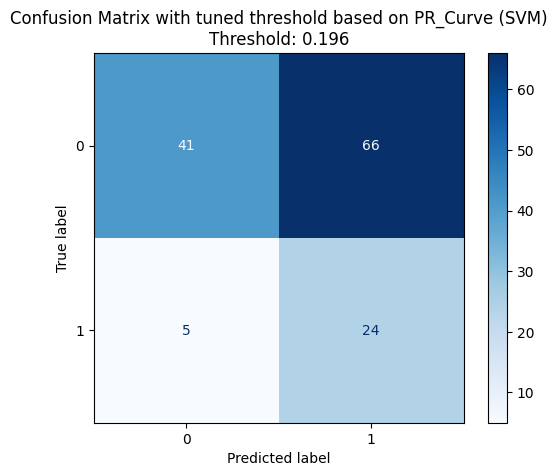

In [24]:
print("WITH THRESHOLD TUNING (Precision-Recall Optimal)")
# The function automatically calculates the best PR threshold if we don't force one
y_tuned = export_results(
    best_bench_model,
    X_test_scaled,
    y_test,
    suffix=f"with tuned threshold based on PR_Curve ({winner_name})",
    save_file=False
)

In [25]:
Counter(y_pred_no_tune == y_tuned)

Counter({np.False_: 90, np.True_: 46})